In [1]:
!pip -q install scikit-learn matplotlib seaborn pandas

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    roc_curve,
    roc_auc_score
)

In [3]:
data = load_breast_cancer()

X = data.data
y = data.target

print("Dataset Shape:", X.shape)
print("Classes:", np.unique(y))

Dataset Shape: (569, 30)
Classes: [0 1]


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [5]:
logistic = LogisticRegression(max_iter=10000)

logistic.fit(X_train, y_train)

y_pred_log = logistic.predict(X_test)

print("Classification Report (Logistic Regression)\n")

print(classification_report(y_test, y_pred_log))

Classification Report (Logistic Regression)

              precision    recall  f1-score   support

           0       0.97      0.93      0.95        42
           1       0.96      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



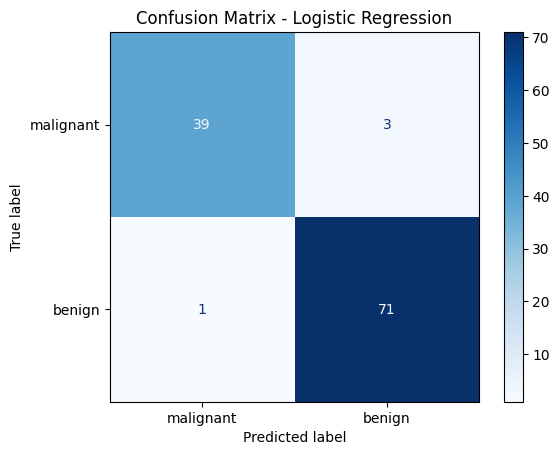

In [6]:
cm = confusion_matrix(y_test, y_pred_log)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=data.target_names
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

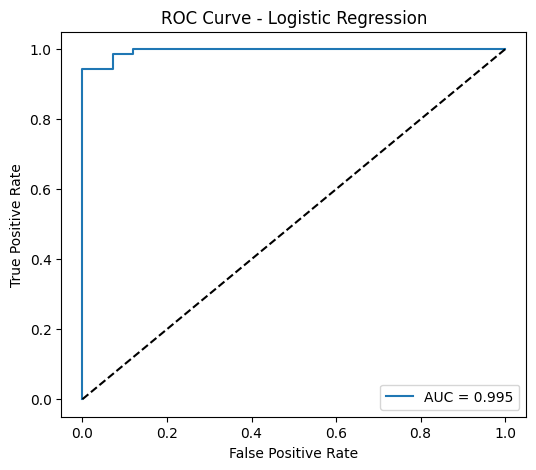

ROC-AUC Score: 0.9953703703703703


In [7]:
y_prob_log = logistic.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob_log)

auc = roc_auc_score(y_test, y_prob_log)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Logistic Regression")

plt.legend()

plt.show()

print("ROC-AUC Score:", auc)

In [8]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Classification Report (Random Forest)\n")

print(classification_report(y_test, y_pred_rf))

Classification Report (Random Forest)

              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [9]:
results = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Random Forest"
    ],

    "Accuracy":[
        accuracy_score(y_test,y_pred_log),
        accuracy_score(y_test,y_pred_rf)
    ],

    "Precision":[
        precision_score(y_test,y_pred_log),
        precision_score(y_test,y_pred_rf)
    ],

    "Recall":[
        recall_score(y_test,y_pred_log),
        recall_score(y_test,y_pred_rf)
    ],

    "ROC-AUC":[
        roc_auc_score(y_test,y_prob_log),
        roc_auc_score(y_test,rf.predict_proba(X_test)[:,1])
    ]

})

results

,Model,Accuracy,Precision,Recall,ROC-AUC
0,Logistic Regression,0.964912,0.959459,0.986111,0.995370
1,Random Forest,0.956140,0.958904,0.972222,0.993717


In [10]:
best = results.sort_values(
    by="Accuracy",
    ascending=False
)

print(best)

                 Model  Accuracy  Precision    Recall   ROC-AUC
0  Logistic Regression  0.964912   0.959459  0.986111  0.995370
1        Random Forest  0.956140   0.958904  0.972222  0.993717
